# InsightLab — Who actually has heart disease, and can we trust the data that says so?

**An end-to-end exploratory data analysis of the UCI Heart Disease databases.**

918 patients, four hospitals, thirteen clinical measurements, one binary question:
does this patient have more than 50% narrowing in a major coronary vessel?

This notebook is written as an *analysis*, not a tutorial. Every section states the
question it is answering, shows the evidence, and commits to a conclusion. Where the
data does not support a conclusion, it says so.

---

## The short version

If you read nothing else:

1. **The four hospitals are not interchangeable.** The disease rate ranges from
   36% (Hungary) to 94% (Switzerland) — a 2.6x spread. Any analysis that pools them
   without accounting for site is measuring the referral policy of four cardiology
   departments as much as it is measuring cardiac physiology.

2. **One cleaning decision reverses a headline finding.** 172 patients have a serum
   cholesterol of `0 mg/dl`, which is not a measurement — it is a missing value wearing
   a number's clothes. Keep those zeros and cholesterol looks *protective*
   (Cliff's delta −0.158). Treat them as missing and the sign flips to the expected
   direction (+0.147). The zeros are concentrated in the sickest hospital.

3. **The strongest single variable is `ca`, and it is 66% missing.** The most useful
   predictor in the dataset is essentially only recorded at Cleveland. The variables
   that are strongest are, systematically, the ones that are least available.

4. **`dropna()` would silently turn this into a Cleveland-only study.** Of the 299
   rows complete on all thirteen clinical fields, 297 are from Cleveland.

5. **The exercise-test variables carry the signal.** Chest pain type, exercise-induced
   angina, maximum heart rate and ST depression all separate the two outcome groups
   substantially. The classic "risk factor" panel — cholesterol, blood pressure,
   fasting blood sugar — barely moves.

---

## 1. Problem statement

### Context

The four databases in the UCI Heart Disease collection were assembled between 1988
and 1991 from patients **referred for coronary angiography** — the invasive test that
directly visualises vessel narrowing. Each record pairs a panel of non-invasive
measurements (history, resting ECG, an exercise stress test) with the angiographic
ground truth.

The original clinical motivation was: *can we predict the angiogram result without
performing the angiogram?* That framing matters, and we will return to it, because
it means **nobody in this dataset is a member of the general public**. Every patient
was already suspicious enough to be sent for an invasive procedure.

### The questions this notebook answers

| # | Question | Section |
|---|----------|---------|
| Q1 | Is this data healthy enough to analyse, and can the four sites be pooled? | 4, 5 |
| Q2 | Which measurements actually separate diseased from non-diseased patients? | 7, 8 |
| Q3 | Does cholesterol — the textbook risk factor — behave as expected? | 9.1 |
| Q4 | Is maximum heart rate just age in disguise? | 9.2 |
| Q5 | Does the sex difference survive controlling for age? | 9.3 |
| Q6 | What must a modeller know before building on this? | 10, 11 |

### Definition of the target

`num` is the angiographic diagnosis, integer 0–4, where 0 means *less than 50%*
narrowing and 1–4 grade the severity above that threshold. The severity grading is
not consistently applied across the four sites, so the entire published literature on
this dataset — and this notebook — collapses it to a binary:

$$\text{disease} = \mathbb{1}[\texttt{num} > 0]$$

---

## 2. Setup

The analysis logic lives in `src/`: `src/data.py` owns acquisition and cleaning,
`src/helpers.py` owns the statistics and every figure. Keeping them out of the
notebook means the cleaning is reviewable as code and the notebook stays readable
as an argument.

In [1]:
import sys, warnings
from pathlib import Path

# Make `src/` importable whether the notebook is run from repo root or notebooks/.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from scipy import stats

from src import data as D
from src import helpers as H

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)

H.set_style()
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.5 | numpy 2.4.6


---

## 3. The data

**Source.** UCI Machine Learning Repository, dataset 45 — *Heart Disease*
(Janosi, Steinbrunn, Pfisterer & Detrano, 1989). Licensed **CC BY 4.0**.
See [`DATASET_CARD.md`](../DATASET_CARD.md) for provenance, collection conditions,
and the ethical caveats on reuse.

`src/data.py` downloads the archive once into `data/raw/` (git-ignored) and caches
it, so re-running this notebook needs no network.

**Structure.** UCI ships four separate files, one per collecting hospital, in an
identical 14-column format. We stack them and keep a `site` column. That column is
usually discarded in tutorials built on this dataset. Discarding it is the single
biggest mistake you can make here — the rest of this notebook is largely a
demonstration of why.

In [2]:
raw = D.load_raw()          # sentinels -> NaN, nothing else touched
print(f"Raw: {raw.shape[0]} rows x {raw.shape[1]} columns")
raw.head()

Raw: 920 rows x 15 columns


,site,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,Cleveland,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,Cleveland,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,Cleveland,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,Cleveland,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,Cleveland,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
# Data dictionary, transcribed from the UCI documentation.
pd.DataFrame(
    [(c, D.COLUMN_DESCRIPTIONS[c]) for c in ["site"] + D.RAW_COLUMNS],
    columns=["column", "meaning"],
).style.hide(axis="index")

column,meaning
site,Hospital that collected the record
age,Age in years
sex,Biological sex
cp,Chest pain type reported on admission
trestbps,Resting blood pressure on admission (mm Hg)
chol,Serum cholesterol (mg/dl)
fbs,Fasting blood sugar > 120 mg/dl
restecg,Resting electrocardiographic result
thalach,Maximum heart rate achieved during exercise test (bpm)
exang,Exercise-induced angina


The coded categoricals are worth spelling out, because several of the codes are
counter-intuitive and one of them drives the headline result:

| Variable | Codes |
|---|---|
| `cp` — chest pain type | 1 typical angina · 2 atypical angina · 3 non-anginal pain · **4 asymptomatic** |
| `restecg` | 0 normal · 1 ST-T wave abnormality · 2 left-ventricular hypertrophy |
| `slope` — peak exercise ST segment | 1 upsloping · 2 flat · 3 downsloping |
| `thal` — thallium stress test | 3 normal · 6 fixed defect · 7 reversible defect |
| `ca` | count of major vessels (0–3) coloured by fluoroscopy |
| `oldpeak` | ST depression induced by exercise, relative to rest (mm) |

Note that `cp = 4` means *asymptomatic* — no chest pain at all. Hold onto that.

---

## 4. Data quality audit

> **Q1: is this data healthy enough to analyse?**

Before any distribution or correlation, three questions: what is missing, what is
*pretending* not to be missing, and what is duplicated.

### 4.1 Missingness is a property of the hospital, not of the variable

The overall missing-rate table looks like an ordinary "some columns are patchy"
situation. It is not.

In [4]:
H.missingness(raw)

,missing,missing_pct,present
ca,611,66.4,309
thal,486,52.8,434
slope,309,33.6,611
fbs,90,9.8,830
oldpeak,62,6.7,858
trestbps,59,6.4,861
thalach,55,6.0,865
exang,55,6.0,865
chol,30,3.3,890
restecg,2,0.2,918


Read that column-wise and you would conclude `ca` is a poorly-recorded variable.
Read it *by site* and the real structure appears.

findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


WindowsPath('C:/Users/sakan/Desktop/InsightLab/figures/01_missingness_by_site.png')

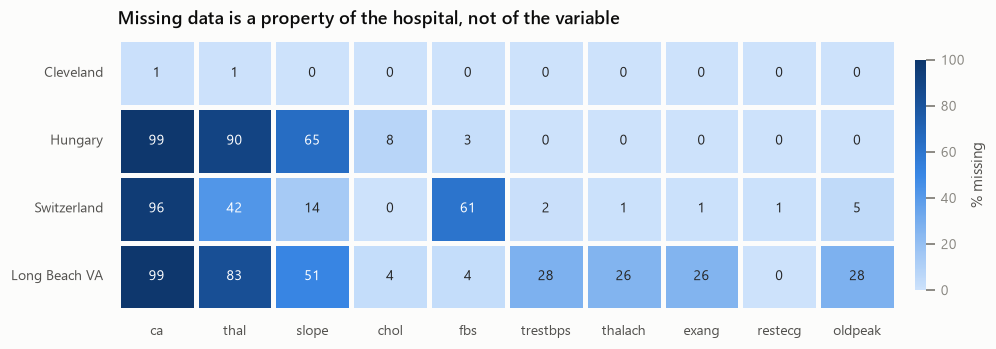

In [5]:
fig = H.plot_missingness_by_site(raw)
H.save_fig(fig, "01_missingness_by_site")

This is not random missingness. It is four different data collection protocols:

- **Cleveland** recorded essentially everything (max 1.3% missing on any field).
- **Hungary** and **Long Beach VA** almost never performed fluoroscopy — `ca` is 99%
  missing at both.
- **Switzerland** skipped fasting blood sugar for 61% of patients.
- **Long Beach VA** is missing ~28% of the *entire exercise test block* together
  (`trestbps`, `thalach`, `exang`, `oldpeak`) — those patients did not do the test.

The practical consequence: **missingness here is a near-perfect proxy for site.**
Any imputation that ignores `site` will impute Cleveland's distribution into
hospitals that never ran the measurement.

### 4.2 The disguised missing values

The dangerous missing values are the ones that are not `NaN`. A physiologically
impossible zero is a missing value that will silently participate in every mean,
median and correlation you compute.

In [6]:
impossible = pd.DataFrame({
    "chol == 0": raw.groupby("site", observed=True)["chol"].apply(lambda s: (s == 0).sum()),
    "trestbps == 0": raw.groupby("site", observed=True)["trestbps"].apply(lambda s: (s == 0).sum()),
    "n": raw.groupby("site", observed=True).size(),
})
impossible["chol == 0  (%)"] = (impossible["chol == 0"] / impossible["n"] * 100).round(1)
impossible

,chol == 0,trestbps == 0,n,chol == 0 (%)
site,,,,
Cleveland,0,0,303,0.0
Hungary,0,0,294,0.0
Switzerland,123,0,123,100.0
Long Beach VA,49,1,200,24.5


**Every single Switzerland patient has a recorded cholesterol of zero**, as does a
quarter of Long Beach VA. A serum cholesterol of 0 mg/dl is incompatible with life;
this is the "not measured" code for these two sites.

This matters far more than it first appears, because Switzerland also has the
**highest disease rate in the dataset**. The zeros are not spread evenly across the
outcome — they are concentrated in the sick group. Section 9.1 quantifies exactly
how badly that corrupts the cholesterol result.

In [7]:
# One resting blood pressure of 0 as well - same treatment.
raw.loc[raw["trestbps"] == 0, ["site", "age", "sex", "trestbps", "chol", "num"]]

,site,age,sex,trestbps,chol,num
753,Long Beach VA,55.0,1.0,0.0,0.0,3


### 4.3 Duplicates and the cleaning log

`src/data.py::clean` applies the steps below and returns an audit log, so nothing
happens to the data invisibly.

In [8]:
df, cleaning_log = D.clean(raw)
cleaning_log

,step,column,values_affected,note
0,zero -> NaN,chol,172,Serum cholesterol of 0 mg/dl is incompatible w...
1,zero -> NaN,trestbps,1,A resting blood pressure of 0 mm Hg is incompa...
2,derive,disease,509,num > 0 -> disease = 1
3,drop rows,-,2,Exact duplicates across all clinical fields


Two records are exact duplicates across all thirteen clinical fields. With no patient
identifier we cannot distinguish a genuine double-entry from two patients who happen
to match on every measurement; we drop them, and note that the choice moves nothing
(2 rows out of 920).

**One step we deliberately did *not* take: imputation.** Given 4.1, filling `ca` or
`chol` would be inventing Cleveland data for Hungarian patients. Every statistic
below is computed on the rows where the relevant variable is actually present, and
every table reports its own `n`.

In [9]:
print(f"Clean: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Dropped {len(raw) - len(df)} duplicate rows; converted "
      f"{int(raw['chol'].eq(0).sum() + raw['trestbps'].eq(0).sum())} impossible zeros to NaN.")
df.head()

Clean: 918 rows x 16 columns
Dropped 2 duplicate rows; converted 173 impossible zeros to NaN.


,site,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,disease
0,Cleveland,63.0,Male,Typical angina,145.0,233.0,Yes,LV hypertrophy,150.0,No,2.3,Downsloping,0.0,Fixed defect,0,0
1,Cleveland,67.0,Male,Asymptomatic,160.0,286.0,No,LV hypertrophy,108.0,Yes,1.5,Flat,3.0,Normal,2,1
2,Cleveland,67.0,Male,Asymptomatic,120.0,229.0,No,LV hypertrophy,129.0,Yes,2.6,Flat,2.0,Reversible defect,1,1
3,Cleveland,37.0,Male,Non-anginal pain,130.0,250.0,No,Normal,187.0,No,3.5,Downsloping,0.0,Normal,0,0
4,Cleveland,41.0,Female,Atypical angina,130.0,204.0,No,LV hypertrophy,172.0,No,1.4,Upsloping,0.0,Normal,0,0


---

## 5. The site problem

Before univariate analysis, we have to settle whether these four files are one
dataset or four.

WindowsPath('C:/Users/sakan/Desktop/InsightLab/figures/02_disease_rate_by_site.png')

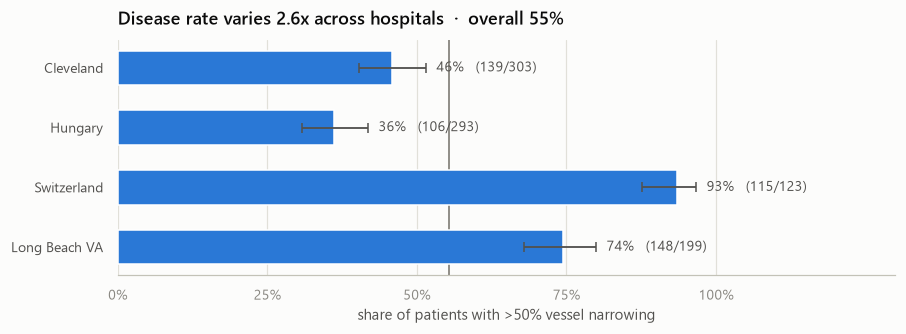

In [10]:
fig = H.plot_target_by_site(df)
H.save_fig(fig, "02_disease_rate_by_site")

In [11]:
site_profile = df.groupby("site", observed=True).agg(
    n=("disease", "size"),
    disease_rate=("disease", "mean"),
    mean_age=("age", "mean"),
    male_share=("sex", lambda s: (s == "Male").mean()),
    chol_recorded=("chol", lambda s: s.notna().mean()),
).round(3)
site_profile

,n,disease_rate,mean_age,male_share,chol_recorded
site,,,,,
Cleveland,303,0.459,54.439,0.680,1.000
Hungary,293,0.362,47.823,0.727,0.925
Switzerland,123,0.935,55.317,0.919,0.000
Long Beach VA,199,0.744,59.357,0.970,0.719


The sites differ on almost everything at once:

- **Disease rate**: 36% (Hungary) to 94% (Switzerland).
- **Sex mix**: 68% male at Cleveland, 97% male at Long Beach VA — a Veterans
  Affairs hospital, so this is expected and is exactly the kind of thing that
  confounds a naive sex effect.
- **Age**: mean 47.8 (Hungary) to 59.4 (VA).
- **Data completeness**: 100% of Cleveland's cholesterol recorded, 0% of Switzerland's.

Switzerland's 94% disease rate tells us its 123 patients were referred under a much
stricter threshold — only near-certain cases got the angiogram. This is
**referral bias**, and it is a property of the hospital's policy, not of Swiss
cardiac health.

**Decision for the rest of the notebook:** we pool the sites, because 918 patients
support conclusions that 303 cannot, but we treat `site` as a confounder that must
be checked rather than a column to be dropped. Where a finding could plausibly be a
site artefact, we re-test it within a single site.

### 5.1 What complete-case analysis would cost

The reflexive fix for missing data is `df.dropna()`. Here is what that actually does.

findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


Keep everything                                            n= 918  disease=55.3%
Drop rows missing any of the 11 non-ca/thal fields         n= 462  disease=56.5%
Complete cases (all 13 clinical fields)                    n= 299  disease=46.5%


WindowsPath('C:/Users/sakan/Desktop/InsightLab/figures/03_completeness_cascade.png')

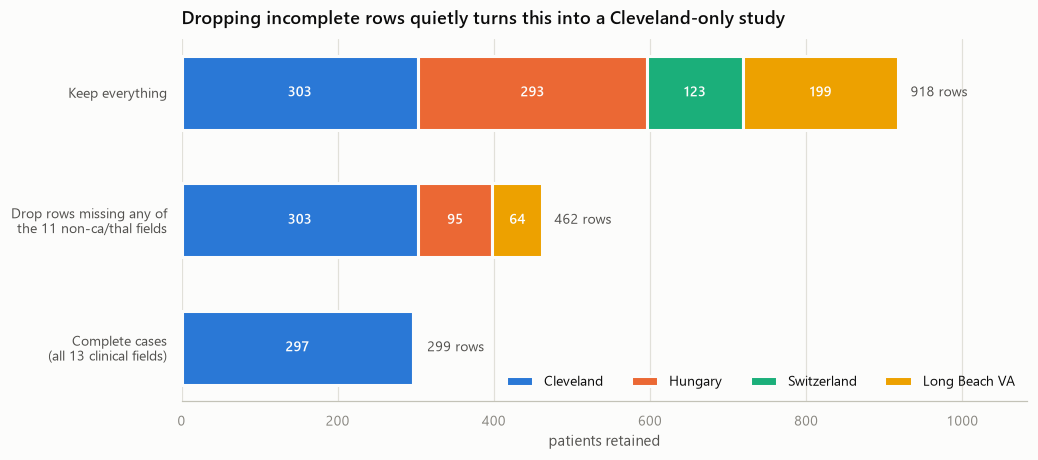

In [12]:
clinical = [c for c in D.RAW_COLUMNS if c != "num"]
core = [c for c in clinical if c not in ("ca", "thal")]

policies = {
    "Keep everything": df,
    "Drop rows missing any of\nthe 11 non-ca/thal fields": df[df[core].notna().all(axis=1)],
    "Complete cases\n(all 13 clinical fields)": df[df[clinical].notna().all(axis=1)],
}
for name, frame in policies.items():
    print(f"{name.replace(chr(10), ' '):58s} n={len(frame):4d}  "
          f"disease={frame['disease'].mean():.1%}")

fig = H.plot_completeness_cascade(policies)
H.save_fig(fig, "03_completeness_cascade")

**`dropna()` on all thirteen clinical fields leaves 299 patients, 297 of them from
Cleveland.** A single line of "cleaning" would have thrown away three hospitals and
two thirds of the data, converted a four-site study into a single-site study, and
changed the base rate from 55% to 47% — all without printing a warning.

Even the gentler policy — dropping only `ca` and `thal`, the two fluoroscopy/thallium
columns — retains 462 rows but still eliminates **all** of Switzerland, because
Switzerland has no cholesterol at all.

This is the practical argument for column-wise `n` over row-wise deletion, and it is
why every table in this notebook carries its own sample size.

---

## 6. Univariate analysis

What does one variable at a time look like?

### 6.1 The target

In [13]:
target_counts = df["num"].value_counts().sort_index()
print("Angiographic severity grade (num):")
print(target_counts.to_string())
print(f"\nBinary target: {df['disease'].sum()} of {len(df)} patients "
      f"({df['disease'].mean():.1%}) have >50% narrowing.")

Angiographic severity grade (num):
num
0    410
1    265
2    108
3    107
4     28

Binary target: 508 of 918 patients (55.3%) have >50% narrowing.


The classes are close to balanced (55/45). That is *not* a population prevalence —
it is the hit rate of a referral pipeline. Roughly half the people sent for an
angiogram in these four hospitals turned out to have significant disease.

### 6.2 Continuous variables

In [14]:
H.numeric_summary(df, D.NUMERIC_COLS)

,n,missing,mean,sd,min,q1,median,q3,max,skew
variable,,,,,,,,,,
age,918,0,53.51,9.43,28.0,47.0,54.0,60.0,77.0,-0.20
trestbps,858,60,132.29,18.53,80.0,120.0,130.0,140.0,200.0,0.63
chol,717,201,246.87,58.56,85.0,210.0,240.0,277.0,603.0,1.31
thalach,863,55,137.54,25.94,60.0,120.0,140.0,157.0,202.0,-0.21
oldpeak,856,62,0.88,1.09,-2.6,0.0,0.5,1.5,6.2,1.04


findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


WindowsPath('C:/Users/sakan/Desktop/InsightLab/figures/04_numeric_distributions.png')

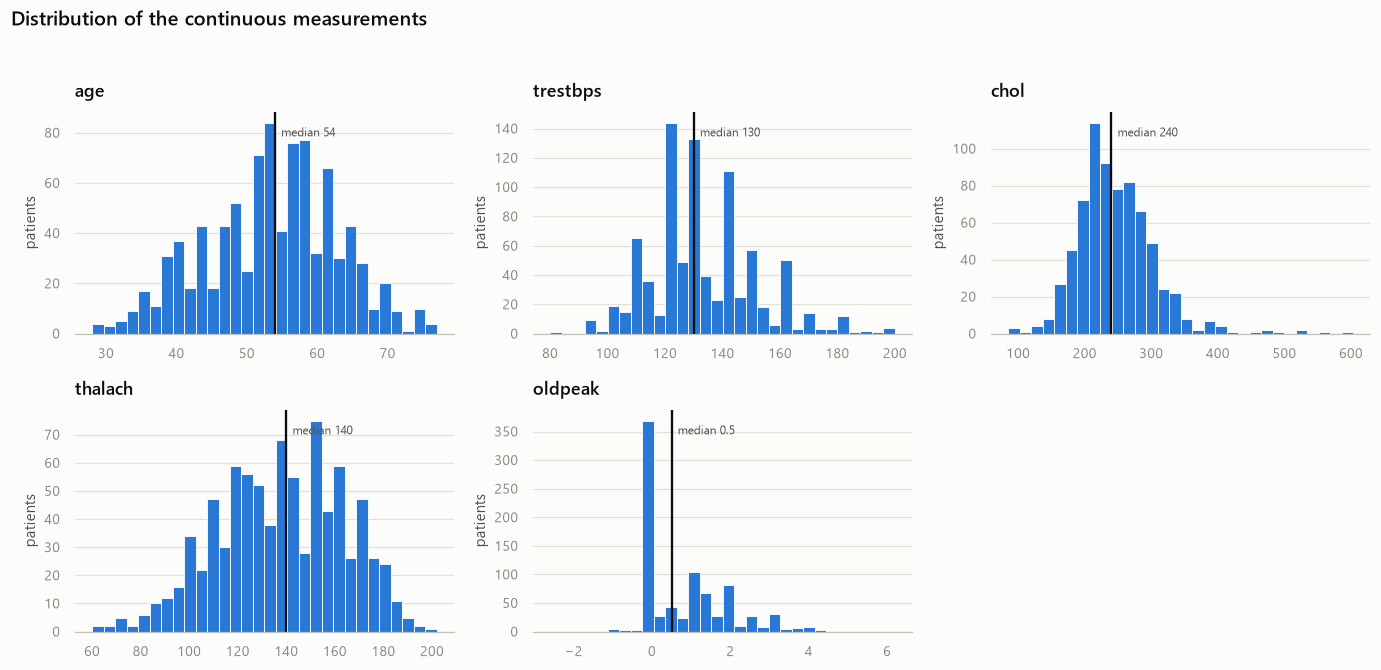

In [15]:
fig = H.plot_numeric_distributions(df, D.NUMERIC_COLS)
H.save_fig(fig, "04_numeric_distributions")

Reading these:

- **`age`** is near-symmetric around 54 (range 28–77) — narrow, because this is a
  referred cardiology population, not a general one.
- **`trestbps`** and **`chol`** are right-skewed (skew 0.63 and 1.31) with long upper
  tails. The maximum cholesterol of 603 mg/dl is extreme but clinically real
  (severe familial hypercholesterolaemia), so we keep it — an outlier is only an
  error if you can argue it is one.
- **`thalach`** (max heart rate) is broad and slightly left-skewed.
- **`oldpeak`** is heavily zero-inflated: the median is 0.0 because most patients
  show no exercise-induced ST depression at all.

The skew in `chol` and `oldpeak` is why every test below is **rank-based**
(Mann-Whitney U, Spearman, Cliff's delta) rather than a t-test or Pearson.

In [16]:
# oldpeak has 12 negative values. Worth a look before assuming they are errors.
negatives = df[df["oldpeak"] < 0]
print(f"{len(negatives)} negative oldpeak values, min {df['oldpeak'].min()}")
negatives.groupby("site", observed=True).size()

12 negative oldpeak values, min -2.6


site
Switzerland      11
Long Beach VA     1
dtype: int64

Negative `oldpeak` means ST *elevation* rather than depression during exercise. It is
an unusual but genuine ECG finding, and 11 of the 12 come from Switzerland — a site
whose recording conventions already look distinct. We keep them and flag them as a
known wrinkle rather than silently clipping to zero.

### 6.3 Categorical variables

WindowsPath('C:/Users/sakan/Desktop/InsightLab/figures/05_categorical_counts.png')

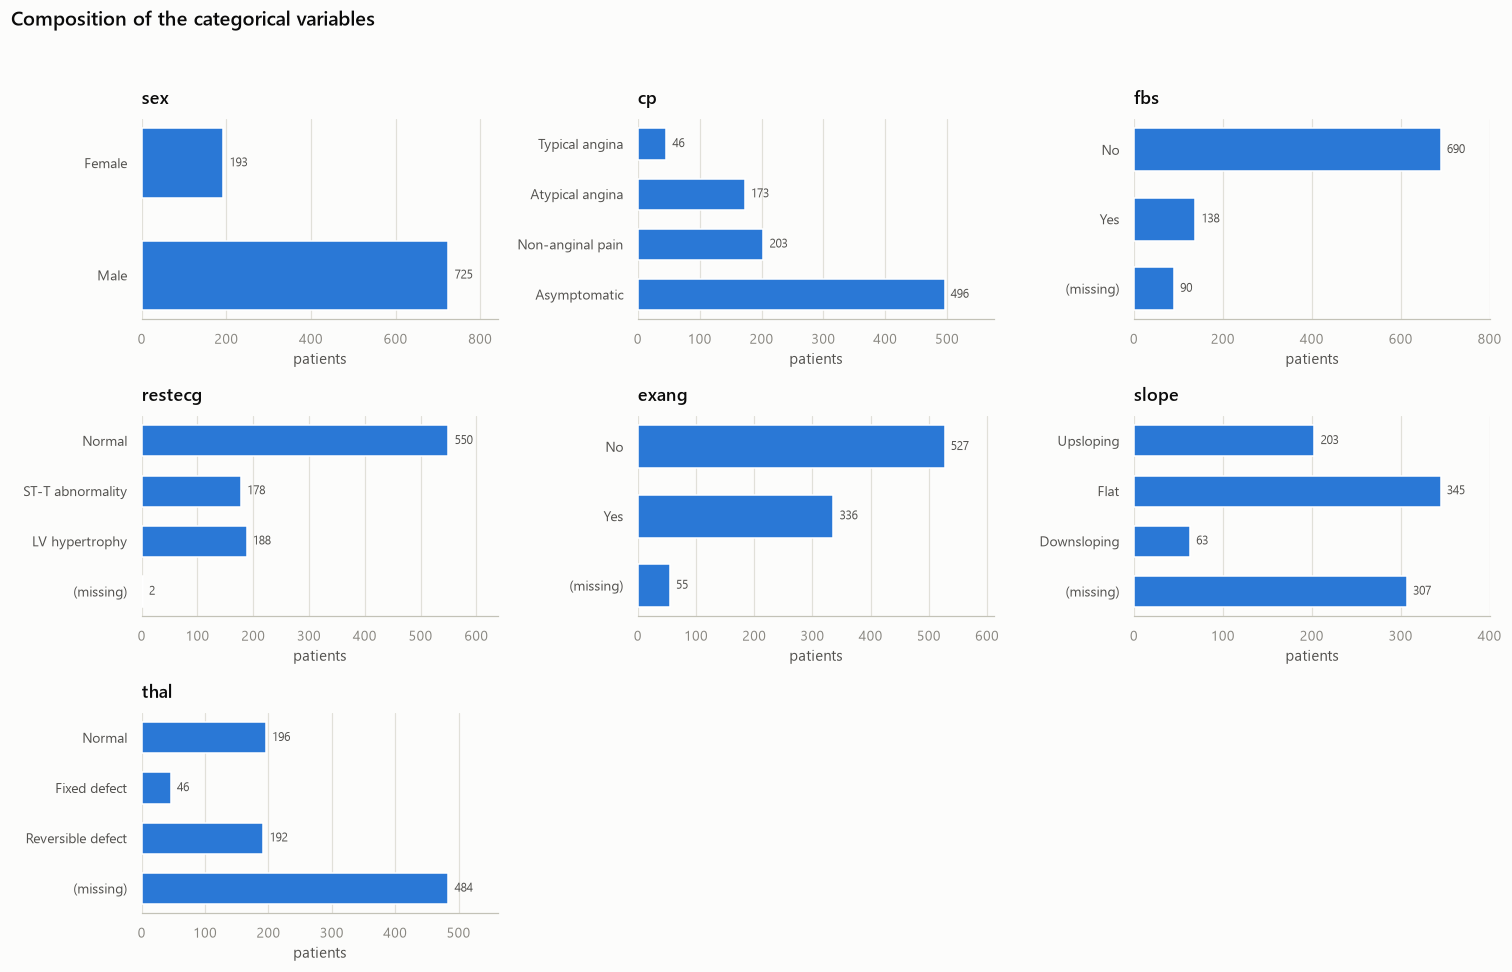

In [17]:
fig = H.plot_categorical_counts(df, D.CATEGORICAL_COLS)
H.save_fig(fig, "05_categorical_counts")

The composition is lopsided in ways that constrain what we can conclude:

- **79% of patients are male** (725 vs 193). Any female subgroup analysis will be
  underpowered, and the 66–80 age band contains only 15 women.
- **54% are `Asymptomatic`** on chest pain — the largest single category is
  "no chest pain".
- `slope`, `thal` and `ca` carry large `(missing)` bars, restating section 4.1.

---

## 7. Bivariate analysis

> **Q2: which measurements actually separate the two outcome groups?**

Two effect sizes are used throughout, both bounded and both rank/contingency based
so they can be compared on one axis:

- **Cliff's delta** for continuous vs binary: $P(X_{disease} > X_{healthy}) - P(X_{disease} < X_{healthy})$.
  Conventional reading: |δ| < 0.147 negligible, < 0.33 small, < 0.474 medium, else large.
- **Cramér's V** (bias-corrected) for categorical vs binary, on 0–1.

Effect sizes rather than p-values, because at n ≈ 900 almost everything is
"significant" and significance says nothing about whether an effect is large enough
to matter.

### 7.1 Continuous measurements against the outcome

In [18]:
comparison = H.compare_numeric_by_target(df, D.NUMERIC_COLS)
comparison

,n_used,median_no_disease,median_disease,difference,cliffs_delta,effect,p_value
variable,,,,,,,
thalach,863,151.0,128.0,-23.0,-0.461267,medium,1.677000e-31
oldpeak,856,0.0,1.1,1.1,0.446370,medium,7.584029e-32
age,918,51.0,57.0,6.0,0.336110,medium,1.805694e-18
chol,717,233.0,248.0,15.0,0.147460,small,6.387087e-04
trestbps,858,130.0,130.0,0.0,0.123565,negligible,1.730573e-03


WindowsPath('C:/Users/sakan/Desktop/InsightLab/figures/06_numeric_by_target.png')

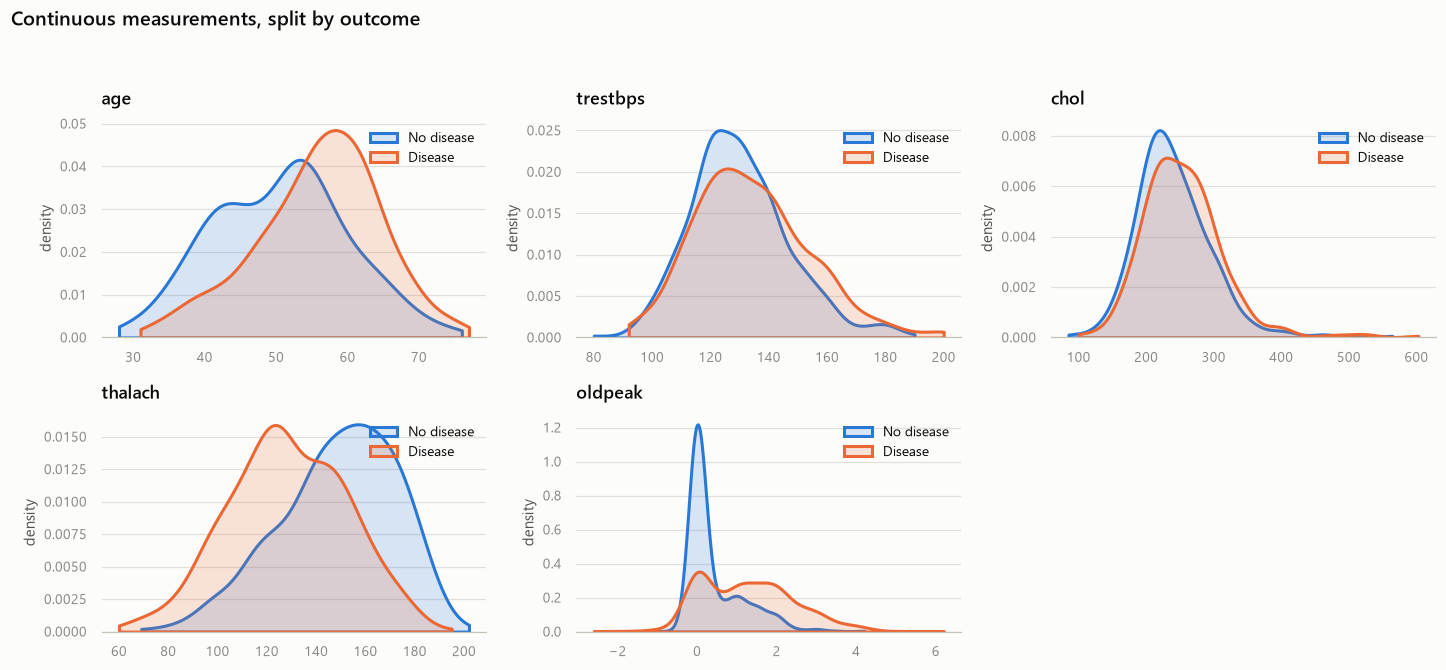

In [19]:
fig = H.plot_numeric_by_target(df, D.NUMERIC_COLS)
H.save_fig(fig, "06_numeric_by_target")

Three variables carry real separation, two do not:

| Variable | Median (no disease → disease) | δ | Verdict |
|---|---|---|---|
| `thalach` | 151 → 128 bpm | −0.461 | **medium** — the strongest continuous signal |
| `oldpeak` | 0.0 → 1.1 mm | +0.446 | **medium** |
| `age` | 51 → 57 yr | +0.336 | medium |
| `chol` | 233 → 248 mg/dl | +0.147 | small, right at the negligible boundary |
| `trestbps` | 130 → 130 mm Hg | +0.124 | **negligible — identical medians** |

The two textbook risk factors are the two weakest. Resting blood pressure has an
*identical median* in both groups. Cholesterol scrapes past negligible — and section
9.1 shows even that is fragile.

What does separate the groups is the **response to exercise**: patients with disease
cannot raise their heart rate as far (`thalach`), and their ECG shows more ST
depression when they try (`oldpeak`).

### 7.2 Categorical variables against the outcome

WindowsPath('C:/Users/sakan/Desktop/InsightLab/figures/07_disease_rate_by_category.png')

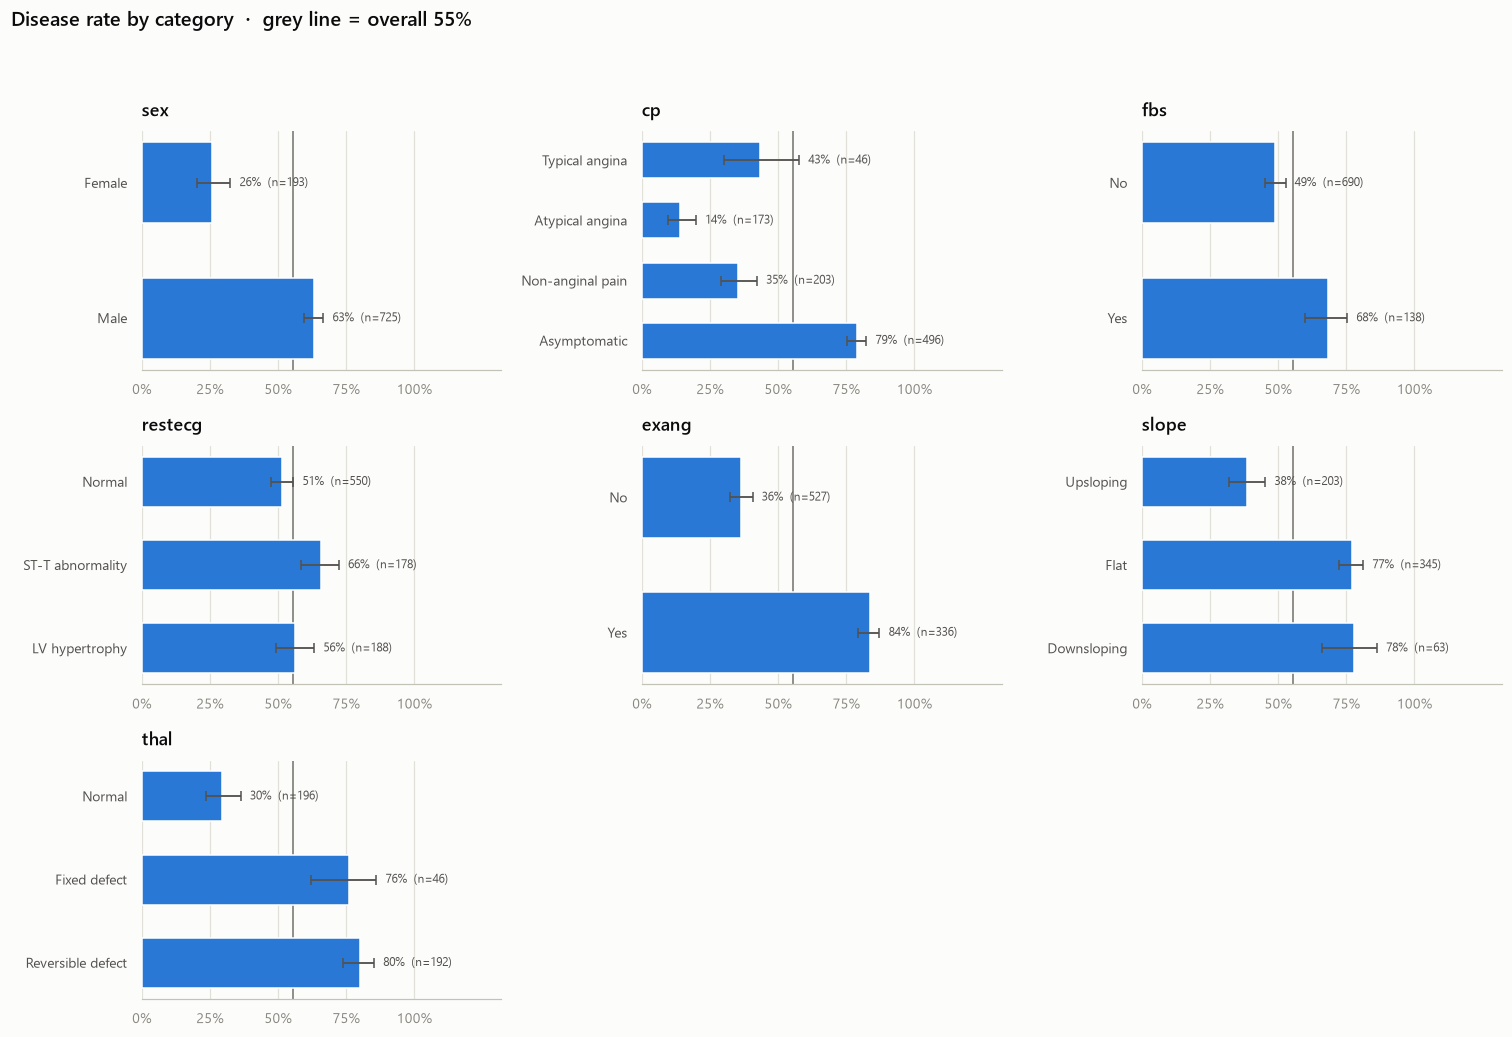

In [20]:
fig = H.plot_rate_by_category(df, D.CATEGORICAL_COLS)
H.save_fig(fig, "07_disease_rate_by_category")

In [21]:
for col in ["cp", "exang", "thal"]:
    print(f"--- {col} ---")
    print(H.rate_by_category(df, col).round(3).to_string(), "\n")

--- cp ---
                    n  cases   rate  ci_low  ci_high
level                                               
Typical angina     46     20  0.435   0.302    0.578
Atypical angina   173     24  0.139   0.095    0.198
Non-anginal pain  203     72  0.355   0.292    0.423
Asymptomatic      496    392  0.790   0.752    0.824 

--- exang ---
         n  cases   rate  ci_low  ci_high
level                                    
No     527    192  0.364   0.324    0.406
Yes    336    281  0.836   0.793    0.872 

--- thal ---
                     n  cases   rate  ci_low  ci_high
level                                                
Normal             196     58  0.296   0.236    0.363
Fixed defect        46     35  0.761   0.621    0.861
Reversible defect  192    154  0.802   0.740    0.852 



**The chest pain result is the counter-intuitive one, and it is the strongest single
association in the dataset.**

| `cp` | n | disease rate |
|---|---|---|
| Atypical angina | 173 | **13.9%** |
| Non-anginal pain | 203 | 35.5% |
| Typical angina | 46 | 43.5% |
| **Asymptomatic** | 496 | **79.0%** |

Patients reporting *no chest pain at all* have a 79% disease rate — nearly six times
that of patients with atypical angina. Taken naively this says chest pain protects
you from heart disease.

It does not. This is referral bias made visible. To be sent for an invasive angiogram
*without* the classic presenting symptom, a patient needed some other compelling
reason — a bad stress test, a strong risk profile, a prior event. The asymptomatic
group is pre-selected for high suspicion. The symptomatic groups include people
investigated *because* they complained, many of whom turn out to have
non-cardiac chest pain.

The lesson generalises: **in a referred cohort, the reason a patient entered the
dataset is itself a variable, and it is usually not recorded.**

The other categoricals behave more conventionally:

- **`exang`** (exercise-induced angina): 83.6% vs 36.4% — a 2.3x gap.
- **`thal`**: reversible defect 80.2% and fixed defect 76.1% vs normal 29.6%.
- **`slope`**: flat 77.1% and downsloping 77.8% vs upsloping 38.4%.
- **`sex`**: male 63.2% vs female 25.9% (revisited in 9.3).
- **`restecg`** and **`fbs`** barely move the needle.

### 7.3 Everything on one axis

In [22]:
ranking = H.target_association_ranking(df, D.NUMERIC_COLS, D.CATEGORICAL_COLS)
ranking

,kind,strength,measure,n_used
variable,,,,
cp,categorical,0.537639,Cramer's V,918
thal,categorical,0.497205,Cramer's V,434
exang,categorical,0.461434,Cramer's V,863
thalach,continuous,0.461267,|Cliff's delta|,863
oldpeak,continuous,0.446370,|Cliff's delta|,856
slope,categorical,0.377326,Cramer's V,611
age,continuous,0.336110,|Cliff's delta|,918
sex,categorical,0.303820,Cramer's V,918
chol,continuous,0.147460,|Cliff's delta|,717


WindowsPath('C:/Users/sakan/Desktop/InsightLab/figures/08_association_ranking.png')

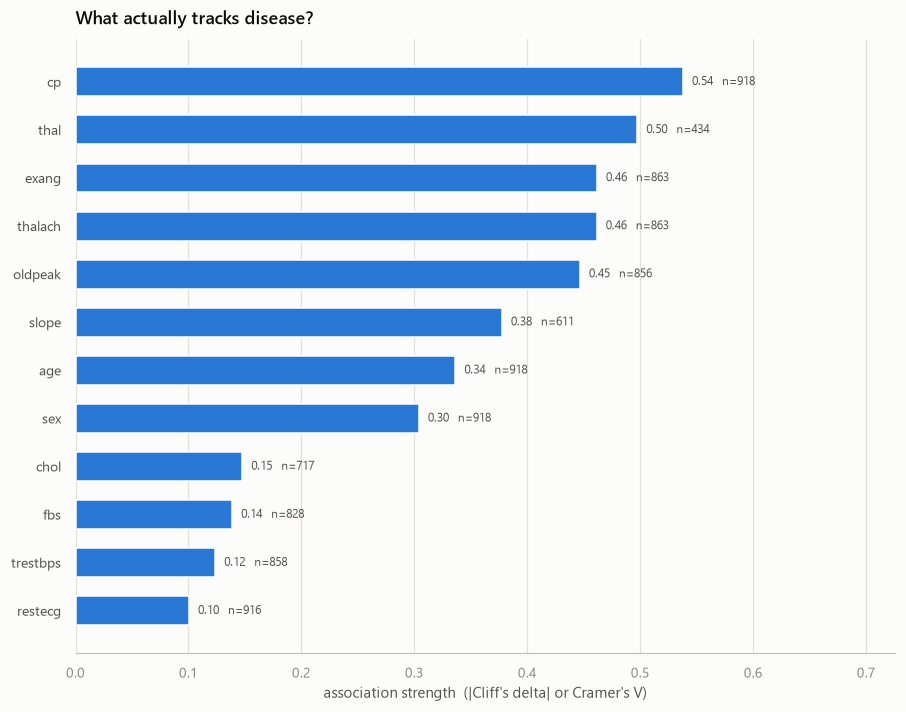

In [23]:
fig = H.plot_association_ranking(ranking)
H.save_fig(fig, "08_association_ranking")

The ranking splits cleanly into three tiers:

1. **Exercise-test variables** (`cp` 0.54, `thal` 0.50, `exang` 0.46, `thalach` 0.46,
   `oldpeak` 0.45, `slope` 0.38) — everything that describes how the heart behaves
   under load.
2. **Demographics** (`age` 0.34, `sex` 0.30) — real, moderate.
3. **Resting risk factors** (`chol` 0.15, `fbs` 0.14, `trestbps` 0.12,
   `restecg` 0.10) — barely distinguishable from noise.

**Read the `n` column alongside the strength.** `thal` ranks second at 0.497 but is
computed on 434 of 918 patients. This is the recurring trap of this dataset: the
variables that discriminate best are the invasive follow-up tests, which were only
ordered for patients already under suspicion — and only at Cleveland.

---

## 8. Correlations

Correlation between the *predictors*, not just with the target — because two
predictors saying the same thing is a problem a model inherits.

WindowsPath('C:/Users/sakan/Desktop/InsightLab/figures/09_correlation_heatmap.png')

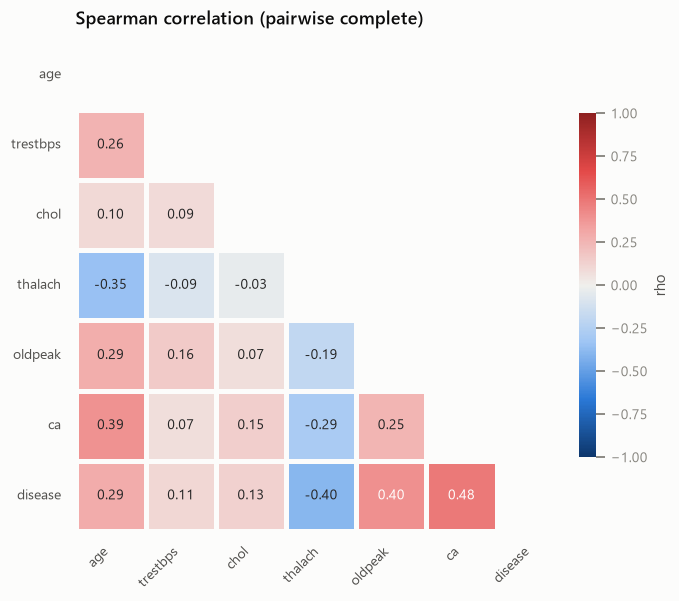

In [24]:
corr_cols = D.NUMERIC_COLS + ["ca", "disease"]
corr = H.spearman_matrix(df, corr_cols)
fig = H.plot_correlation_heatmap(corr, "Spearman correlation (pairwise complete)")
H.save_fig(fig, "09_correlation_heatmap")

Against the target: `ca` +0.484, `oldpeak` +0.402, `thalach` −0.398, `age` +0.290,
`chol` +0.128, `trestbps` +0.107.

**`ca` is the single strongest correlate in the dataset — and it is 66% missing.**
It counts how many major vessels lit up under fluoroscopy, which is close to a direct
measurement of the thing we are predicting, and it is available almost only at
Cleveland. It is simultaneously the most predictive and least usable column here.

Among the predictors themselves, the notable pair is `age`–`thalach` at **−0.347**:
older patients reach lower maximum heart rates. Since `thalach` is our best
continuous predictor and `age` is a known risk factor, we have to ask whether
`thalach` is carrying independent information at all. Section 9.2 tests it.

Correlations are **pairwise complete** — each cell uses the rows where both variables
are present, so different cells rest on different subsets. Given section 4.1 that is
the honest choice, but it means the matrix is not internally consistent the way a
complete-case matrix would be.

WindowsPath('C:/Users/sakan/Desktop/InsightLab/figures/10_categorical_association_matrix.png')

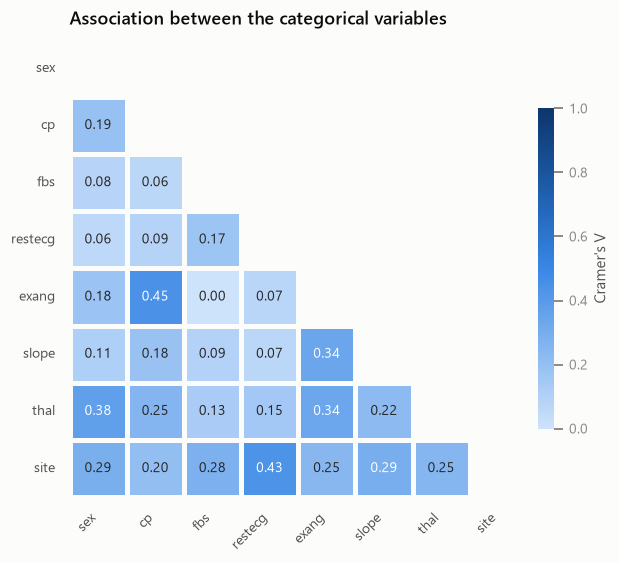

In [25]:
cats = D.CATEGORICAL_COLS + ["site"]
assoc = pd.DataFrame(
    [[1.0 if a == b else H.cramers_v(df[a], df[b]) for b in cats] for a in cats],
    index=cats, columns=cats,
)
fig = H.plot_categorical_association_matrix(assoc)
H.save_fig(fig, "10_categorical_association_matrix")

`site` is entangled with the clinical variables, which is the quantitative version of
the warning in section 5:

- `site` ↔ `restecg` = **0.43** — the four hospitals graded resting ECGs differently.
- `site` ↔ `sex` = 0.29, `site` ↔ `slope` = 0.29, `site` ↔ `fbs` = 0.28.

A model given these columns and not given `site` will reconstruct `site` from them
and partly learn "which hospital is this?" instead of "is this patient sick?".

Among the clinical variables, `cp` ↔ `exang` = 0.45 is the strongest pair — both
describe angina, so the overlap is expected rather than alarming.

---

## 9. Hypothesis checks

Three specific claims, each tested rather than asserted.

### 9.1 Q3 — Does cholesterol behave the way the textbook says?

**H₀:** cholesterol does not differ between the two outcome groups.

This is the section that justifies the whole data-quality audit. We run the
comparison twice: once treating `chol == 0` as a real measurement, once treating it
as missing. Nothing else changes.

In [26]:
naive = raw.assign(disease=(raw["num"] > 0).astype(int))   # zeros kept as data
cleaned = df                                               # zeros -> NaN

for label, frame in [("zeros kept as data", naive), ("zeros treated as missing", cleaned)]:
    sub = frame[["chol", "disease"]].dropna()
    pos = sub.loc[sub["disease"] == 1, "chol"]
    neg = sub.loc[sub["disease"] == 0, "chol"]
    delta = H.cliffs_delta(pos.to_numpy(), neg.to_numpy())
    _, p = stats.mannwhitneyu(pos, neg, alternative="two-sided")
    print(f"{label:28s}  n={len(sub):3d}  median {neg.median():.0f} -> {pos.median():.0f} mg/dl"
          f"   delta={delta:+.3f}   p={p:.2e}")

zeros kept as data            n=890  median 228 -> 218 mg/dl   delta=-0.158   p=4.94e-05
zeros treated as missing      n=717  median 233 -> 248 mg/dl   delta=+0.147   p=6.39e-04


WindowsPath('C:/Users/sakan/Desktop/InsightLab/figures/11_cholesterol_sign_flip.png')

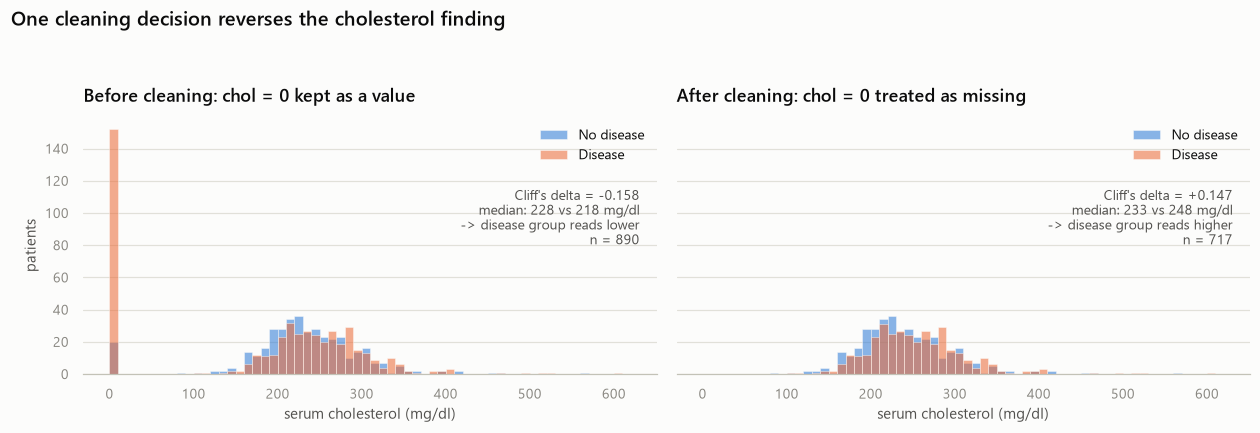

In [27]:
fig = H.plot_cholesterol_sign_flip(naive, cleaned)
H.save_fig(fig, "11_cholesterol_sign_flip")

**The conclusion reverses sign.**

| | n | median (healthy → diseased) | Cliff's δ | Reads as |
|---|---|---|---|---|
| Zeros kept as data | 890 | 228 → 218 mg/dl | **−0.158** | cholesterol is *protective* (p = 4.9e-05) |
| Zeros treated as missing | 717 | 233 → 248 mg/dl | **+0.147** | cholesterol is a *risk factor* (p = 6e-04) |

**Mechanism.** Switzerland has 100% zero-cholesterol *and* a 93.5% disease rate. Every
one of those 123 fake zeros lands in the diseased group, dragging its apparent
cholesterol down below the healthy group's. The left panel shows this directly —
the spike at zero is almost entirely orange.

Both results are "statistically significant". Both would survive a careless review.
One of them is an artefact of a missing-value code, and no amount of statistical
rigour downstream would have caught it — only looking at the data would.

**Verdict on Q3:** after cleaning, cholesterol is *directionally* consistent with the
textbook (diseased patients ~15 mg/dl higher) but the effect is **small — δ = +0.147,
right at the negligible boundary** and weaker than every exercise-test variable. And
we should hold even that loosely: the 201 patients whose cholesterol is unknown are
not a random sample, so this estimate is computed on a biased subset.

A useful check is whether the effect survives inside a single site, removing the
site confound entirely:

In [28]:
cle = df[df["site"] == "Cleveland"][["chol", "disease"]].dropna()
delta_cle = H.cliffs_delta(
    cle.loc[cle["disease"] == 1, "chol"].to_numpy(),
    cle.loc[cle["disease"] == 0, "chol"].to_numpy(),
)
_, p_cle = stats.mannwhitneyu(cle.loc[cle["disease"] == 1, "chol"],
                              cle.loc[cle["disease"] == 0, "chol"])
print(f"Cleveland only (complete cholesterol): n={len(cle)}  delta={delta_cle:+.3f}  p={p_cle:.4f}")

Cleveland only (complete cholesterol): n=303  delta=+0.140  p=0.0354


Within Cleveland alone — where cholesterol is 100% recorded and no site mixing is
possible — δ = +0.140, p = 0.035. The direction and magnitude hold. The positive
association is real; it is just small.

### 9.2 Q4 — Is maximum heart rate just age in disguise?

`thalach` is the strongest continuous predictor (δ = −0.461), but it correlates with
age at ρ = −0.347, and age predicts disease on its own. If `thalach` is only a proxy
for age it adds nothing.

**Test:** stratify into age bands and re-measure the effect *inside* each band. If it
survives everywhere, age does not explain it away.

In [29]:
banded = df.assign(
    age_band=pd.cut(df["age"], [28, 45, 55, 65, 80], labels=["29-45", "46-55", "56-65", "66-80"])
)

rows = []
for band, group in banded.groupby("age_band", observed=True):
    sub = group[["thalach", "disease"]].dropna()
    pos = sub.loc[sub["disease"] == 1, "thalach"]
    neg = sub.loc[sub["disease"] == 0, "thalach"]
    delta = H.cliffs_delta(pos.to_numpy(), neg.to_numpy())
    rows.append({
        "age_band": band, "n": len(sub),
        "median_no_disease": neg.median(), "median_disease": pos.median(),
        "cliffs_delta": round(delta, 3), "effect": H.interpret_delta(delta),
    })
pd.DataFrame(rows).set_index("age_band")

,n,median_no_disease,median_disease,cliffs_delta,effect
age_band,,,,,
29-45,193,165.0,140.0,-0.457,medium
46-55,300,150.0,125.0,-0.448,medium
56-65,298,144.0,125.0,-0.317,small
66-80,71,134.5,125.0,-0.297,small


findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


WindowsPath('C:/Users/sakan/Desktop/InsightLab/figures/12_thalach_within_age_bands.png')

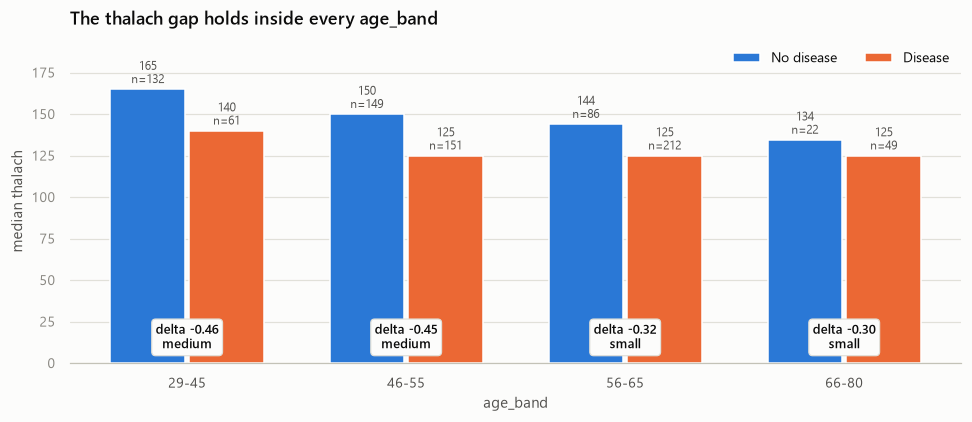

In [30]:
fig = H.plot_effect_within_bands(banded, value="thalach", band="age_band")
H.save_fig(fig, "12_thalach_within_age_bands")

**Verdict on Q4: no, `thalach` is not merely age.**

The effect persists in all four bands (δ = −0.46, −0.45, −0.32, −0.30), and in the
two youngest bands it is *as strong as the unstratified estimate*. A 40-year-old with
disease reaches a median 140 bpm against 165 for a healthy peer of the same age — a
25 bpm gap that has nothing to do with ageing.

The attenuation in the older bands is worth noting: by 66–80 the gap narrows to 125
vs 134 bpm. Two plausible explanations, which this dataset cannot separate — older
healthy patients are already closer to the diseased ceiling, or the oldest bands are
thinner (n = 71) and noisier. Flag it; do not resolve it.

### 9.3 Q5 — Does the sex difference survive age?

Male patients show a 63.2% disease rate against 25.9% for female patients. But the
sites differ sharply in sex mix (97% male at the VA, which also has a 74% disease
rate), so this could be site or age rather than sex.

In [31]:
sex_age = (
    banded.groupby(["age_band", "sex"], observed=True)["disease"]
    .agg(n="size", disease_rate="mean").round(3)
)
sex_age

n  disease_rate
age_band sex                      
29-45    Female   48         0.104
         Male    147         0.381
46-55    Female   74         0.189
         Male    242         0.603
56-65    Female   56         0.500
         Male    268         0.754
66-80    Female   15         0.200
         Male     67         0.806

The gap holds in every age band: 10.4% vs 38.1% (29–45), 18.9% vs 60.3% (46–55),
50.0% vs 75.4% (56–65), 20.0% vs 80.6% (66–80).

**Verdict on Q5: the direction is robust, the magnitude is not trustworthy.**

The pattern survives age stratification, and a male excess in coronary disease is
well established clinically. But two things block a clean estimate from *this* data:

- The **66–80 female cell contains 15 patients**. Its 20% rate has a 95% Wilson
  interval of roughly 7–45% — it is compatible with almost anything, and the apparent
  *reversal* of the age trend in women is far more likely to be noise than signal.
- **Sex and site are confounded** (Cramér's V = 0.29). Women are 32% of Cleveland
  (46% disease rate) and 3% of the VA (74% disease rate), so pooled female patients
  are drawn disproportionately from the lower-prevalence hospital.

We can say men in this cohort were more likely to have disease. We cannot use these
numbers to estimate by how much in any general population.

---

## 10. Feature engineering preview

Not a model — a preview of what modelling would have to confront, and one honest
negative result.

In [32]:
fe = df.copy()

# 1. Chronotropic deficit: how far short of the age-predicted maximum the patient fell.
#    Combines age and thalach into the quantity a cardiologist actually reads.
fe["hr_reserve_deficit"] = (220 - fe["age"]) - fe["thalach"]

# 2. Any exercise-induced ST depression at all - oldpeak is zero-inflated,
#    so the presence/absence split may carry the signal better than the magnitude.
fe["st_depressed"] = np.where(fe["oldpeak"].notna(), (fe["oldpeak"] > 0).astype(float), np.nan)

# 3. How much of this patient's record is missing - a site proxy, and a leakage risk.
fe["n_missing"] = fe[clinical].isna().sum(axis=1)

candidates = []
for name, col in [("thalach (raw)", "thalach"), ("hr_reserve_deficit", "hr_reserve_deficit"),
                  ("oldpeak (raw)", "oldpeak"), ("n_missing", "n_missing")]:
    sub = fe[[col, "disease"]].dropna()
    delta = H.cliffs_delta(sub.loc[sub["disease"] == 1, col].to_numpy(),
                           sub.loc[sub["disease"] == 0, col].to_numpy())
    candidates.append({"feature": name, "n": len(sub), "cliffs_delta": round(delta, 3),
                       "effect": H.interpret_delta(delta)})

pd.DataFrame(candidates).set_index("feature")

,n,cliffs_delta,effect
feature,,,
thalach (raw),863,-0.461,medium
hr_reserve_deficit,863,0.372,medium
oldpeak (raw),856,0.446,medium
n_missing,918,0.055,negligible


**The engineered heart-rate feature is worse than the raw one.** `hr_reserve_deficit`
scores δ = +0.372 against `thalach`'s −0.461. Folding age into the feature by
subtraction *destroys* information, because the model can use age and `thalach`
separately and weight them independently. Reported here rather than quietly dropped:
domain-plausible feature engineering routinely loses to the raw column, and the only
way to know is to measure.

`st_depressed` (any ST depression at all) gives a 70.2% vs 35.0% split on 856
patients — nearly all of `oldpeak`'s signal from a single binary, which is worth
knowing if interpretability matters.

In [33]:
# Does the binary "any ST depression" split retain oldpeak's signal?
H.rate_by_category(fe.assign(st=fe["st_depressed"].map({0.0: "No", 1.0: "Yes"})), "st").round(3)

,n,cases,rate,ci_low,ci_high
level,,,,,
No,380,133,0.350,0.304,0.399
Yes,476,334,0.702,0.659,0.741


In [34]:
print("n_missing as a site fingerprint:")
print(fe.groupby("site", observed=True)["n_missing"].mean().round(2).to_string())

leak = H.cliffs_delta(
    fe.loc[fe["disease"] == 1, "n_missing"].to_numpy(),
    fe.loc[fe["disease"] == 0, "n_missing"].to_numpy(),
)
print(f"\nn_missing vs disease: delta={leak:+.3f} ({H.interpret_delta(leak)})")

n_missing as a site fingerprint:
site
Cleveland        0.02
Hungary          2.66
Switzerland      3.22
Long Beach VA    3.74

n_missing vs disease: delta=+0.055 (negligible)


Missingness per row runs from 0.02 fields at Cleveland to 3.74 at Long Beach VA — it
identifies the hospital almost perfectly. Its direct association with the target is
negligible (δ = +0.055), so it is not leaking the outcome, but any missingness
indicator handed to a model is effectively handing it `site`.

**What a modelling pass would have to decide, in order:**

1. **Site strategy** — pool with `site` as a feature, stratify, or fit per-site.
   Not a detail; it changes what the model is estimating.
2. **`ca` and `thal`** — drop them (lose the two strongest signals) or keep them
   (restrict to Cleveland). There is no free option.
3. **Validation split** — a random split leaks site structure. Grouping by site
   (train on three hospitals, test on the fourth) measures something much closer to
   what deployment would demand.
4. **Metric** — 55/45 is balanced enough that accuracy is not actively misleading,
   but the clinical cost of a false negative and a false positive are nowhere near
   equal.

---

## 11. Findings and conclusion

### Answers to the questions

**Q1 — Is the data healthy, and can the sites be pooled?**
Healthy enough to analyse, not healthy enough to trust naively. 172 cholesterol
values and 1 blood pressure were impossible zeros. Missingness is structural and
site-determined, not random. The sites can be pooled only if `site` is carried
through as a confounder — their disease rates span 36% to 94%.

**Q2 — What separates the outcome groups?**
The exercise test, decisively. `cp` (V = 0.54), `thal` (0.50), `exang` (0.46),
`thalach` (δ = −0.46), `oldpeak` (+0.45) and `slope` (0.38) lead. Demographics follow
(`age` 0.34, `sex` 0.30). The resting risk-factor panel — cholesterol, fasting blood
sugar, resting blood pressure, resting ECG — is last, all below 0.15.

**Q3 — Does cholesterol behave as expected?**
Only after cleaning, and only weakly. Keeping the fake zeros makes cholesterol look
protective (δ = −0.158); removing them flips it to +0.147, confirmed within Cleveland
alone (+0.140). The textbook direction is right; the effect is small and rests on a
non-random 78% of patients.

**Q4 — Is `thalach` just age?**
No. The effect survives in all four age bands (δ = −0.46 to −0.30) and is strongest
in the youngest patients.

**Q5 — Does the sex difference survive age?**
The direction does, in every band. The magnitude is not estimable here: 15 women in
the oldest band, and sex is confounded with site at V = 0.29.

**Q6 — What must a modeller know?**
That `ca` is the strongest predictor and 66% missing; that `dropna()` yields a
Cleveland-only dataset; that a random train/test split leaks site; and that `cp`'s
apparent protective effect of chest pain is referral bias, not physiology.

### The three findings worth carrying away

1. **A missing-value code reversed a headline result.** Cholesterol read as
   protective until 172 zeros were recognised as "not measured". The failure was
   invisible to every downstream statistic and detectable only by looking at the
   data. *This is the entire argument for doing EDA before modelling.*

2. **Predictive power and availability are inversely related.** `ca` (ρ = +0.484)
   is 66% missing; `thal` (V = 0.50) is 53% missing. The best signals come from
   invasive follow-up tests ordered only for already-suspicious patients at one
   hospital. Strength and usability pull in opposite directions.

3. **How a patient entered the dataset is a variable, and it is not recorded.**
   Asymptomatic patients have a 79% disease rate against 13.9% for atypical angina —
   because getting an angiogram without symptoms required other strong evidence.
   Every number here describes a referred cardiology population, not a public.

### Limitations

- **Not a general population.** Every patient was referred for angiography. The 55%
  base rate is a referral hit rate; nothing here estimates population prevalence.
- **Collected 1988–1991.** Diagnostic thresholds, imaging and treatment have all
  moved. This is a methods dataset, not current clinical evidence.
- **Missing data is informative and unimputed.** Statistics are computed pairwise on
  varying subsets, so figures are not strictly comparable across variables.
- **Severity collapsed.** `num` 1–4 became a single class, discarding gradation that
  is in any case inconsistent across sites.
- **Association, not causation.** No claim here is causal, and the strongest
  associations (`ca`, `thal`) are near-direct observations of the outcome rather than
  independent risk factors.
- **Underpowered subgroups.** 193 women total, 15 in the oldest band; Switzerland
  contributes only 8 non-diseased patients.

### If this continued

Model with grouped (leave-one-site-out) validation to get an honest generalisation
estimate; formally test whether the exercise-test effects are homogeneous across
sites; and treat missingness as a modelled mechanism rather than a nuisance — at
Long Beach VA, *not having done the exercise test* is itself a clinical decision that
carries information.

---

*InsightLab · Exploratory Data Analysis · Data: UCI Heart Disease (CC BY 4.0).
Figures in [`figures/`](../figures), analysis code in [`src/`](../src).*